# S2 : Baseline Notebook : Assistant radiologue virtuel

## Objectif du notebook

Ce notebook correspond à la première baseline du projet **Assistant radiologue virtuel responsable**.

L’objectif est de construire une première chaîne simple et reproductible permettant de :

1. télécharger et charger le dataset CheXpert ;
2. identifier les fichiers utiles, notamment `train.csv` et `valid.csv` ;
3. préparer les données sous forme de DataFrame ;
4. vérifier l’accès aux images de radiographies thoraciques ;
5. préparer une première base de travail pour la classification en trois classes :

   * `normal`
   * `suspected_opacity`
   * `uncertain`

Cette baseline ne vise pas à produire un diagnostic médical. Elle sert uniquement à valider le pipeline technique du projet : chargement des données, préparation des images, structuration des sorties et reproductibilité.

Le prototype reste donc un outil pédagogique et expérimental, conformément au cadrage du projet.


## 0. Imports

Dans cette partie, nous importons les bibliothèques nécessaires pour charger les données, manipuler les fichiers, lire les CSV, ouvrir les images et calculer quelques métriques simples.

In [5]:
import os
import json
import zipfile
import copy

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## 1. Import des données depuis Kaggle

Nous utilisons `kagglehub` pour télécharger ou retrouver localement le dataset CheXpert.

La variable `path` contient le chemin local du dataset sur l’ordinateur.
Nous parcourons ensuite ce dossier pour vérifier la présence des fichiers CSV, notamment `train.csv` et `valid.csv`.

In [6]:
DATASET_NAME = "ashery/chexpert"

path = kagglehub.dataset_download(DATASET_NAME)

print("Chemin local :", path)

print("\nFichiers CSV trouvés :")
for root, dirs, files in os.walk(path):
    for f in files:
        if f.endswith(".csv"):
            print(os.path.join(root, f))

Chemin local : C:\Users\Baptiste\.cache\kagglehub\datasets\ashery\chexpert\versions\1

Fichiers CSV trouvés :
C:\Users\Baptiste\.cache\kagglehub\datasets\ashery\chexpert\versions\1\train.csv
C:\Users\Baptiste\.cache\kagglehub\datasets\ashery\chexpert\versions\1\valid.csv


## 2. Création du DataFrame principal

Nous chargeons le fichier `train.csv` dans un DataFrame pandas.

Selon l’environnement utilisé, le fichier peut être stocké comme un CSV classique ou comme un fichier compressé.
Pour rendre le notebook compatible entre Windows et Mac, nous vérifions si le fichier est compressé avec `zipfile.is_zipfile()`.

Le DataFrame obtenu contient les chemins des images, le type de vue, les informations patient anonymisées et les labels associés aux radiographies.

In [7]:
file_path = "train.csv"
csv_path = os.path.join(path, "train.csv")

if zipfile.is_zipfile(csv_path):
    df = pd.read_csv(csv_path, compression="zip")
else:
    df = pd.read_csv(csv_path)

df.head()

,Path,Sex,Age,Frontal/Lateral,AP/PA,No Finding,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices
0,CheXpert-v1.0-small/train/patient00001/study1/...,Female,68,Frontal,AP,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,1.0
1,CheXpert-v1.0-small/train/patient00002/study2/...,Female,87,Frontal,AP,NaN,NaN,-1.0,1.0,NaN,-1.0,-1.0,NaN,-1.0,NaN,-1.0,NaN,1.0,NaN
2,CheXpert-v1.0-small/train/patient00002/study1/...,Female,83,Frontal,AP,NaN,NaN,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN
3,CheXpert-v1.0-small/train/patient00002/study1/...,Female,83,Lateral,NaN,NaN,NaN,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN
4,CheXpert-v1.0-small/train/patient00003/study1/...,Male,41,Frontal,AP,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN


In [8]:
print("Dimensions du DataFrame :", df.shape)

print("\nColonnes disponibles :")
for col in df.columns:
    print("-", col)

Dimensions du DataFrame : (223414, 19)

Colonnes disponibles :
- Path
- Sex
- Age
- Frontal/Lateral
- AP/PA
- No Finding
- Enlarged Cardiomediastinum
- Cardiomegaly
- Lung Opacity
- Lung Lesion
- Edema
- Consolidation
- Pneumonia
- Atelectasis
- Pneumothorax
- Pleural Effusion
- Pleural Other
- Fracture
- Support Devices


## 3. Nettoyage simple des métadonnées

Dans cette partie, nous créons une version numérique de certaines colonnes textuelles du dataset.

Les colonnes concernées sont :
- `Sex` : `Male` devient 0, `Female` devient 1 ;
- `Frontal/Lateral` : `Frontal` devient 0, `Lateral` devient 1 ;
- `AP/PA` : `AP` devient 0, `PA` devient 1.

Cette transformation peut être utile pour certaines analyses ou pour des modèles classiques de machine learning.
Pour la baseline Gemma 4, elle n’est pas centrale, car le modèle utilisera surtout l’image et le prompt. Nous la conservons comme préparation secondaire du dataset.

In [9]:
def numeric_df(df):
    new_df = copy.deepcopy(df)

    sexes = {"Male": 0, "Female": 1}
    new_df["Sex"] = new_df["Sex"].map(sexes)

    axes = {"Frontal": 0, "Lateral": 1}
    new_df["Frontal/Lateral"] = new_df["Frontal/Lateral"].map(axes)

    ap_pa_dict = {"AP": 0, "PA": 1}
    new_df["AP/PA"] = new_df["AP/PA"].map(ap_pa_dict)

    return new_df

In [10]:
os.makedirs("cleaned", exist_ok=True)

for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith(".csv"):
            csv_file = os.path.join(root, file)

            if zipfile.is_zipfile(csv_file):
                df_tmp = pd.read_csv(csv_file, compression="zip")
            else:
                df_tmp = pd.read_csv(csv_file)

            df_tmp = numeric_df(df_tmp)

            name_file, ext = os.path.splitext(file)
            output_file = os.path.join("cleaned", f"{name_file}_cleaned{ext}")

            df_tmp.to_csv(output_file, index=False)

            print("Fichier nettoyé sauvegardé :", output_file)

Fichier nettoyé sauvegardé : cleaned\train_cleaned.csv
Fichier nettoyé sauvegardé : cleaned\valid_cleaned.csv


## 4. Filtrage des radiographies frontales

Le projet se limite à l’analyse de radiographies thoraciques frontales.

Nous filtrons donc le dataset pour conserver uniquement les lignes dont la colonne `Frontal/Lateral` vaut `Frontal`.

In [11]:
df_frontal = df[df["Frontal/Lateral"] == "Frontal"].copy()

print("Nombre de lignes avant filtrage :", df.shape[0])
print("Nombre de lignes après filtrage frontal :", df_frontal.shape[0])

df_frontal.head()

Nombre de lignes avant filtrage : 223414
Nombre de lignes après filtrage frontal : 191027


,Path,Sex,Age,Frontal/Lateral,AP/PA,No Finding,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices
0,CheXpert-v1.0-small/train/patient00001/study1/...,Female,68,Frontal,AP,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,1.0
1,CheXpert-v1.0-small/train/patient00002/study2/...,Female,87,Frontal,AP,NaN,NaN,-1.0,1.0,NaN,-1.0,-1.0,NaN,-1.0,NaN,-1.0,NaN,1.0,NaN
2,CheXpert-v1.0-small/train/patient00002/study1/...,Female,83,Frontal,AP,NaN,NaN,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN
4,CheXpert-v1.0-small/train/patient00003/study1/...,Male,41,Frontal,AP,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN
5,CheXpert-v1.0-small/train/patient00004/study1/...,Female,20,Frontal,PA,1.0,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN


## 5. Mapping vers les trois classes du projet

CheXpert contient plusieurs labels médicaux.
Pour respecter le périmètre du projet, nous les simplifions en trois classes :

- `normal` : aucune anomalie indiquée par le label `No Finding` ;
- `suspected_opacity` : présence d’un label lié à une opacité, une consolidation ou une pneumonie ;
- `uncertain` : cas non couvert ou ambigu.

La classe `uncertain` est importante, car elle permet d’éviter de forcer une prédiction lorsque le cas est incertain.

In [12]:
def map_to_project_class(row):
    if row.get("No Finding") == 1:
        return "normal"

    if (
        row.get("Lung Opacity") == 1
        or row.get("Consolidation") == 1
        or row.get("Pneumonia") == 1
    ):
        return "suspected_opacity"

    return "uncertain"


df_frontal["project_label"] = df_frontal.apply(map_to_project_class, axis=1)

df_frontal["project_label"].value_counts()

project_label
suspected_opacity    103314
uncertain             70739
normal                16974
Name: count, dtype: int64

## 6. Création d’un échantillon de baseline

Pour cette première baseline, nous ne travaillons pas sur tout le dataset.

Nous créons un petit échantillon équilibré avec le même nombre d’images par classe.
Cela permet de tester rapidement le pipeline tout en gardant une exécution reproductible.

In [16]:
N_PER_CLASS = 10
RANDOM_STATE = 42

samples = []

for label in df_frontal["project_label"].unique():
    df_label = df_frontal[df_frontal["project_label"] == label]

    sample_label = df_label.sample(
        n=min(len(df_label), N_PER_CLASS),
        random_state=RANDOM_STATE
    )

    samples.append(sample_label)

df_sample = pd.concat(samples, ignore_index=True)

df_sample["project_label"].value_counts()

project_label
normal               10
suspected_opacity    10
uncertain            10
Name: count, dtype: int64

In [20]:
df_sample[["Path", "project_label"]].head()

,Path,project_label
0,CheXpert-v1.0-small/train/patient29882/study1/...,normal
1,CheXpert-v1.0-small/train/patient17129/study3/...,normal
2,CheXpert-v1.0-small/train/patient19962/study1/...,normal
3,CheXpert-v1.0-small/train/patient11406/study1/...,normal
4,CheXpert-v1.0-small/train/patient18630/study3/...,normal


## 7. Vérification des chemins d’images

La colonne `Path` contient le chemin relatif de chaque image.

Nous construisons un chemin complet vers chaque image afin de vérifier qu’elle existe bien sur l’ordinateur.

In [21]:
def build_image_path(relative_path):
    relative_path = relative_path.replace("CheXpert-v1.0-small/", "")
    return os.path.join(path, relative_path)


df_sample["full_image_path"] = df_sample["Path"].apply(build_image_path)
df_sample["image_exists"] = df_sample["full_image_path"].apply(os.path.exists)

df_sample[["Path", "full_image_path", "image_exists"]].head()

,Path,full_image_path,image_exists
0,CheXpert-v1.0-small/train/patient29882/study1/...,C:\Users\Baptiste\.cache\kagglehub\datasets\as...,True
1,CheXpert-v1.0-small/train/patient17129/study3/...,C:\Users\Baptiste\.cache\kagglehub\datasets\as...,True
2,CheXpert-v1.0-small/train/patient19962/study1/...,C:\Users\Baptiste\.cache\kagglehub\datasets\as...,True
3,CheXpert-v1.0-small/train/patient11406/study1/...,C:\Users\Baptiste\.cache\kagglehub\datasets\as...,True
4,CheXpert-v1.0-small/train/patient18630/study3/...,C:\Users\Baptiste\.cache\kagglehub\datasets\as...,True


In [22]:
df_sample["image_exists"].value_counts()

image_exists
True    30
Name: count, dtype: int64

## 8. Affichage de quelques images

Nous affichons quelques radiographies de l’échantillon afin de vérifier visuellement que les images sont bien accessibles et associées à un label simplifié.

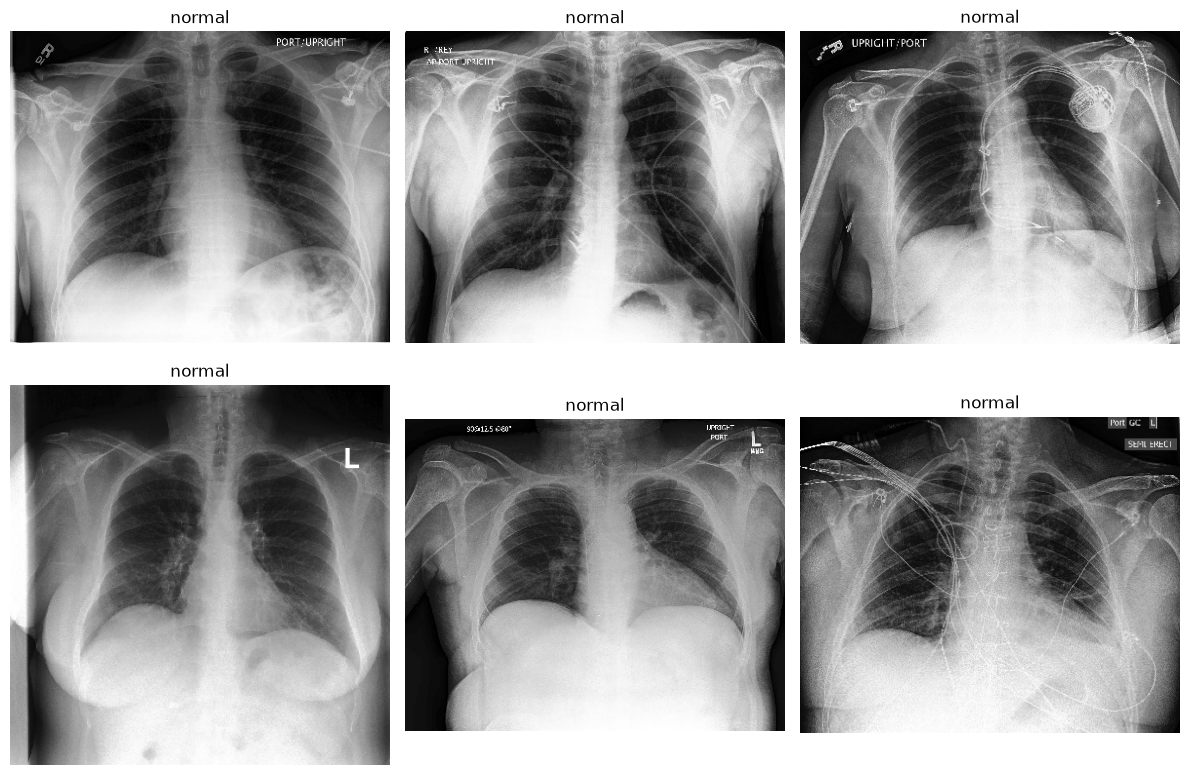

In [23]:
def show_samples(df, n=6):
    plt.figure(figsize=(12, 8))

    for i, (_, row) in enumerate(df.head(n).iterrows()):
        img = Image.open(row["full_image_path"]).convert("L")

        plt.subplot(2, 3, i + 1)
        plt.imshow(img, cmap="gray")
        plt.title(row["project_label"])
        plt.axis("off")

    plt.tight_layout()
    plt.show()


show_samples(df_sample, n=6)

## 9. Prompt baseline Gemma 4

Nous définissons un premier prompt baseline pour Gemma 4.

Le modèle devra répondre uniquement avec un JSON contenant :
- la qualité de l’image ;
- la classe prédite ;
- un score de confiance ;
- des observations visuelles ;
- une justification courte ;
- des limites ;
- un avertissement non clinique.

Cette étape prépare le contrat de sortie attendu par le projet.

In [24]:
BASELINE_PROMPT = """
You are a cautious educational radiology assistant.

You are given a frontal chest X-ray image.
Your task is not to make a medical diagnosis.

Classify the image into exactly one of these classes:
- normal
- suspected_opacity
- uncertain

Return only a valid JSON object with:
{
  "image_quality": "good | medium | poor",
  "predicted_class": "normal | suspected_opacity | uncertain",
  "confidence": float between 0 and 1,
  "visual_evidence": "short factual visual observations",
  "justification": "short explanation",
  "limitations": "what cannot be concluded",
  "warning": "Educational prototype only. Not a medical diagnosis."
}

Rules:
- If the image is unclear or ambiguous, use "uncertain".
- Do not invent clinical information.
- Do not give treatment advice.
- Return JSON only.
"""

## 10. Fonction de prédiction baseline temporaire

Dans un premier temps, nous utilisons une fonction temporaire pour tester le pipeline complet.

Cette fonction sera ensuite remplacée par un appel réel à Gemma 4.
L’intérêt est de valider dès maintenant la structure de sortie, la validation JSON et l’export des résultats.

In [25]:
def predict_baseline(image_path):
    output = {
        "image_quality": "good",
        "predicted_class": "uncertain",
        "confidence": 0.50,
        "visual_evidence": "Baseline placeholder output.",
        "justification": "Gemma model call is not connected yet.",
        "limitations": "Educational prototype only. This output cannot be used as a medical diagnosis.",
        "warning": "Educational prototype only. Not a medical diagnosis."
    }
    return output

## 11. Validation du contrat JSON

Nous vérifions automatiquement que la sortie produite respecte le format attendu.

La validation porte sur :
- la présence des clés obligatoires ;
- la validité de la classe prédite ;
- le format du score de confiance ;
- la présence du warning non clinique.

In [26]:
REQUIRED_KEYS = [
    "image_quality",
    "predicted_class",
    "confidence",
    "visual_evidence",
    "justification",
    "limitations",
    "warning"
]

ALLOWED_CLASSES = ["normal", "suspected_opacity", "uncertain"]

def validate_output(output):
    for key in REQUIRED_KEYS:
        if key not in output:
            return False, f"Clé manquante : {key}"

    if output["predicted_class"] not in ALLOWED_CLASSES:
        return False, "Classe prédite invalide"

    if not isinstance(output["confidence"], (float, int)):
        return False, "La confiance doit être numérique"

    if not 0 <= output["confidence"] <= 1:
        return False, "La confiance doit être comprise entre 0 et 1"

    if "not a medical diagnosis" not in output["warning"].lower():
        return False, "Warning non clinique manquant"

    return True, "Sortie valide"

## 12. Exécution de la baseline sur l’échantillon

Nous appliquons la fonction de prédiction baseline à chaque image de l’échantillon.

Pour chaque image, nous stockons :
- le chemin de l’image ;
- la classe attendue ;
- la classe prédite ;
- le score de confiance ;
- le statut de validation du JSON ;
- le warning.

In [27]:
results = []

for _, row in df_sample.iterrows():
    output = predict_baseline(row["full_image_path"])
    is_valid, validation_message = validate_output(output)

    results.append({
        "image_path": row["full_image_path"],
        "expected_class": row["project_label"],
        "predicted_class": output["predicted_class"],
        "confidence": output["confidence"],
        "json_valid": is_valid,
        "validation_message": validation_message,
        "warning": output["warning"]
    })

results_df = pd.DataFrame(results)

results_df.head()

,image_path,expected_class,predicted_class,confidence,json_valid,validation_message,warning
0,C:\Users\Baptiste\.cache\kagglehub\datasets\as...,normal,uncertain,0.5,True,Sortie valide,Educational prototype only. Not a medical diag...
1,C:\Users\Baptiste\.cache\kagglehub\datasets\as...,normal,uncertain,0.5,True,Sortie valide,Educational prototype only. Not a medical diag...
2,C:\Users\Baptiste\.cache\kagglehub\datasets\as...,normal,uncertain,0.5,True,Sortie valide,Educational prototype only. Not a medical diag...
3,C:\Users\Baptiste\.cache\kagglehub\datasets\as...,normal,uncertain,0.5,True,Sortie valide,Educational prototype only. Not a medical diag...
4,C:\Users\Baptiste\.cache\kagglehub\datasets\as...,normal,uncertain,0.5,True,Sortie valide,Educational prototype only. Not a medical diag...


## 13. Export des résultats

Nous exportons les résultats de la baseline dans un fichier CSV.

Ce fichier pourra être utilisé comme preuve de fonctionnement du pipeline et comme base pour comparer les futures améliorations.

In [28]:
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

output_csv = os.path.join(OUTPUT_DIR, "baseline_results.csv")

results_df.to_csv(output_csv, index=False)

print("Résultats exportés dans :", output_csv)

Résultats exportés dans : outputs\baseline_results.csv


## 14. Métriques simples

Nous calculons quelques métriques simples pour obtenir une première mesure de la baseline.

Avec la fonction temporaire actuelle, les résultats ne sont pas représentatifs d’un vrai modèle, car la prédiction est encore simulée.
Cette section sera surtout utile lorsque l’appel réel à Gemma 4 sera connecté.

In [29]:
y_true = results_df["expected_class"]
y_pred = results_df["predicted_class"]

print("Accuracy:", accuracy_score(y_true, y_pred))

print("\nClassification report:")
print(classification_report(y_true, y_pred))

print("\nConfusion matrix:")
print(confusion_matrix(y_true, y_pred))

Accuracy: 0.3333333333333333

Classification report:
                   precision    recall  f1-score   support

           normal       0.00      0.00      0.00        10
suspected_opacity       0.00      0.00      0.00        10
        uncertain       0.33      1.00      0.50        10

         accuracy                           0.33        30
        macro avg       0.11      0.33      0.17        30
     weighted avg       0.11      0.33      0.17        30


Confusion matrix:
[[ 0  0 10]
 [ 0  0 10]
 [ 0  0 10]]


C:\Users\Baptiste\OneDrive - Efrei\Bureau\Baptiste\Efrei\I1\S6 - efrei\ml\ARVI-RX-S6\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Baptiste\OneDrive - Efrei\Bureau\Baptiste\Efrei\I1\S6 - efrei\ml\ARVI-RX-S6\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Baptiste\OneDrive - Efrei\Bureau\Baptiste\Efrei\I1\S6 - efrei\ml\ARVI-RX-S6\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 

## 15. Conclusion et limites

Cette baseline met en place une première chaîne reproductible :
- chargement du dataset CheXpert ;
- création d’un DataFrame principal ;
- préparation simple des métadonnées ;
- filtrage des radiographies frontales ;
- mapping vers trois classes projet ;
- création d’un échantillon de baseline ;
- vérification de l’accès aux images ;
- définition d’un prompt baseline ;
- validation d’une sortie JSON ;
- export des résultats ;
- calcul de métriques simples.

## Limites

La fonction de prédiction actuelle est temporaire. Elle doit être remplacée par un appel réel à Gemma 4.

Les sorties ne doivent pas être interprétées comme des diagnostics médicaux.
Le prototype reste pédagogique, expérimental et non clinique.

## Prochaine étape

Connecter Gemma 4 au pipeline, comparer les prédictions aux labels attendus, puis améliorer le prompt et la gestion de l’incertitude.